# Red Galaxy Pipeline - Example Usage

This notebook demonstrates how to use the unified `red_galaxy_pipeline` module for red galaxy identification and photometric redshift estimation.
Based on Vakili et al. (2019) methodology.
To determine the red sequence of a photometric catalogue, the code needs to take as input:
- a spec_z catalogue, with the photometric needed to extract the red sequence with a GMM model
- a luminosity function, which is characterized by the apparent magnitude evolution mi_star(z).
Optionnaly, the user can provided as well the slope alpha(z) and the normalization phi(z) of the luminosity function. 
The luminosity function is required to determine photo-z for the red-sequence.

Once all these steps are performed, the user can then determined the red-sequence on the full photo-z catalogue. Exemples with sbatch will be coming soon. 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import gridspec
from red_galaxy_pipeline import RedCatalogue

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Path to your custom font directory
#custom_font_path = "/Users/ler13nrv/Documents/miniconda3/envs/NRV_ENV/fonts/arial.ttf"

# Add the directory to the Matplotlib font manager
#fm.fontManager.addfont(custom_font_path)

plt.rcParams.update({
    'figure.figsize': (3.5,3.5),
    'figure.dpi': 150,
    'font.family': 'Arial',  # Use 'Arial' if preferred
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'axes.grid': False,  # Optional: Set to False if you don't want gridlines
    'grid.alpha': 0.3,
    'font.family':'Arial',
    'text.usetex': False,
    'mathtext.fontset' : "stix"
})


## GMM selection 
The spec-z parquet catalogue needs to have:
- an reference magnitude, it should be a MAG-AUTO magnitude
- the colours that we will used to determine the red-sequence

In the example below, mag_v is the VIS aperture magnitude, while mag_v2 is the Kron magnitude.

Note: The step takes a while as this step incorpates Extreme Deconvolution (XD) Gaussian Mixture Model, which implementation taken from the astroML package (Bovy et al. 2011)
For sake of simplicity, we show here a example on a restricted redshift range 0.1-0.4



In [3]:
# Initialize pipeline with basic configuration
cat = RedCatalogue(
    colors=['gi', 'rz', 'iy'],  # Can also use [('g','i'), ('r','z'), ('i','y')]
    magnitude_col='mag_v2',
    z_spec_col='z_spec',
    z_min=0.05,
    z_max=0.95,
    delta_a=0.05,  # Fine spacing for a(z)
    delta_b=0.10,  # Medium spacing for b(z)
    delta_c=0.15,   # Coarse spacing for c(z)
)

In [4]:
# Load spectroscopic training sample
df_spec = pd.read_parquet('Q1_spec_sample_TOT_05102025_unif.parquet')
print(f"Loaded {len(df_spec)} galaxies with spec-z")

print(df_spec.columns[-18:])
##Best to save the red spec-z catalogue
df_red = cat.select_red_sequence(df_spec,save_filepath='./Q1_red_sample_15012026.parquet')


Loaded 78121 galaxies with spec-z
Index(['mag_v2', 'mag_v2_err', 'mag_v', 'mag_v_err', 'mag_g', 'mag_g_err',
       'mag_y', 'mag_y_err', 'mag_j', 'mag_j_err', 'mag_h', 'mag_h_err',
       'mag_r', 'mag_r_err', 'mag_i', 'mag_i_err', 'mag_z', 'mag_z_err'],
      dtype='object')
Input: 78121 galaxies
After z cuts [0.05, 0.95]: 57716 galaxies
Running GMM on 30 redshift bins (Δz=0.03)
Redshift range: 0.050 to 0.950

  Bin z=[0.050, 0.080): 1329 galaxies, colors=gi, rz, iy
    → Selected 296 red galaxies, m_ref=17.22

  Bin z=[0.080, 0.110): 2144 galaxies, colors=gi, rz, iy
    → Selected 383 red galaxies, m_ref=17.27

  Bin z=[0.110, 0.140): 1527 galaxies, colors=gi, rz, iy
    → Selected 449 red galaxies, m_ref=18.19

  Bin z=[0.140, 0.170): 1868 galaxies, colors=gi, rz, iy
    → Selected 361 red galaxies, m_ref=18.49

  Bin z=[0.170, 0.200): 2887 galaxies, colors=gi, rz, iy
    → Selected 836 red galaxies, m_ref=18.67

  Bin z=[0.200, 0.230): 2296 galaxies, colors=gi, rz, iy
    → Select

/Users/ler13nrv/miniconda3/envs/NRV_ENV/lib/python3.11/site-packages/sklearn/mixture/_base.py:270: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


    → Selected 267 red galaxies, m_ref=20.26

  Bin z=[0.530, 0.560): 1784 galaxies, colors=rz, gi, iy


/Users/ler13nrv/miniconda3/envs/NRV_ENV/lib/python3.11/site-packages/sklearn/mixture/_base.py:270: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


    → Selected 402 red galaxies, m_ref=20.50

  Bin z=[0.560, 0.590): 1445 galaxies, colors=rz, gi, iy


...

    → Selected 528 red galaxies, m_ref=20.84

  Bin z=[0.620, 0.650): 1655 galaxies, colors=rz, gi, iy
    → Selected 403 red galaxies, m_ref=20.75

  Bin z=[0.650, 0.680): 2497 galaxies, colors=rz, gi, iy
    → Selected 518 red galaxies, m_ref=21.07

  Bin z=[0.680, 0.710): 2368 galaxies, colors=rz, gi, iy


/Users/ler13nrv/miniconda3/envs/NRV_ENV/lib/python3.11/site-packages/sklearn/mixture/_base.py:270: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


    → Selected 587 red galaxies, m_ref=21.13

  Bin z=[0.710, 0.740): 2034 galaxies, colors=rz, gi, iy
    → Selected 429 red galaxies, m_ref=21.42

  Bin z=[0.740, 0.770): 1688 galaxies, colors=rz, gi, iy


/Users/ler13nrv/miniconda3/envs/NRV_ENV/lib/python3.11/site-packages/sklearn/mixture/_base.py:270: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


    → Selected 320 red galaxies, m_ref=21.39

  Bin z=[0.770, 0.800): 1617 galaxies, colors=rz, gi, iy
    → Selected 379 red galaxies, m_ref=21.57

  Bin z=[0.800, 0.830): 1881 galaxies, colors=rz, gi, iy
    → Selected 434 red galaxies, m_ref=21.71

  Bin z=[0.830, 0.860): 2101 galaxies, colors=rz, gi, iy
    → Selected 320 red galaxies, m_ref=21.84

  Bin z=[0.860, 0.890): 1682 galaxies, colors=rz, gi, iy
    → Selected 395 red galaxies, m_ref=21.87

  Bin z=[0.890, 0.920): 1363 galaxies, colors=rz, gi, iy
    → Selected 239 red galaxies, m_ref=21.94

  Bin z=[0.920, 0.950): 1551 galaxies, colors=rz, gi, iy
    → Selected 309 red galaxies, m_ref=22.06

Final red sequence sample: 12489 galaxies
Selected red sequence: 12489 galaxies
  (21.6% of z-cut sample)
  Note: Schechter parameters not provided. Skipping L/L* computation.
Saved 12489 red galaxies to ./Q1_red_sample_15012026.parquet


Text(0, 0.5, '$I_E-H_E$')

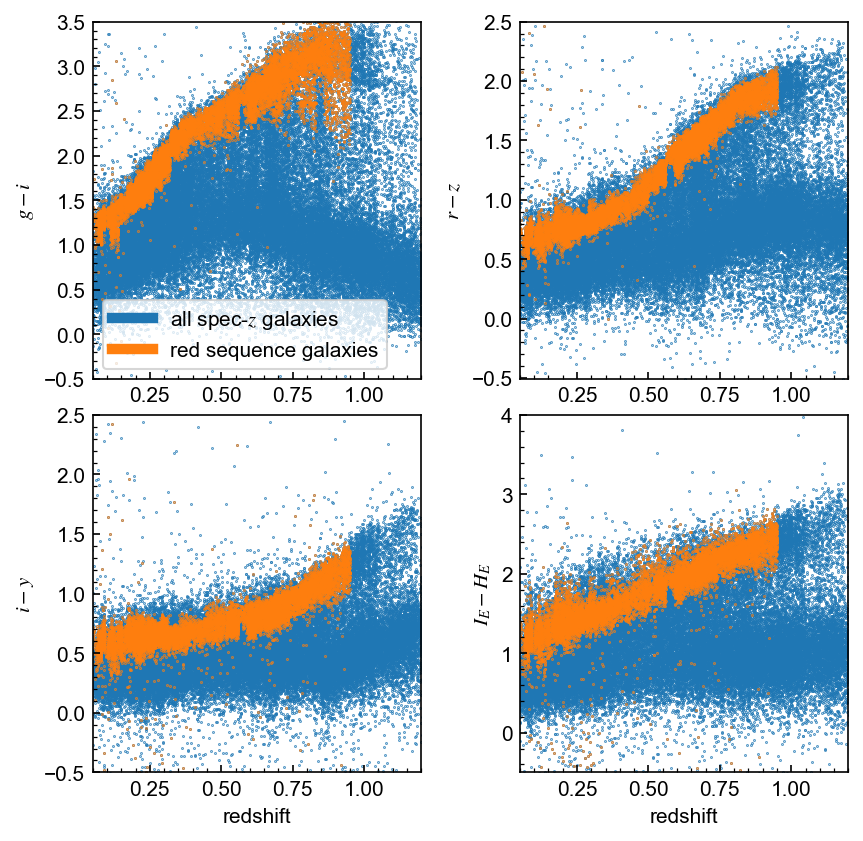

In [6]:
## Now we can plot the results of the GMM code.

from matplotlib.lines import Line2D


fig = plt.figure(figsize=(6.5,6.5))
gs = gridspec.GridSpec(2, 2)
gs.update(hspace=0.1 ,wspace=0.3)
ax = fig.add_subplot(gs[0])

ax.set_xlim(0.05,1.2)
ax.set_ylim(-0.5,3.5)


scatter1=ax.scatter(df_spec.z_spec,df_spec.mag_g - df_spec.mag_i,s=0.1)
scatter2=ax.scatter(df_red.z_spec,df_red.mag_g - df_red.mag_i,s=0.1)

legend_handler = Line2D([0], [0], color=scatter1.get_facecolors()[0], linewidth=5, label=r'all spec-$z$ galaxies')
legend_handler2 = Line2D([0], [0], color=scatter2.get_facecolors()[0], linewidth=5,label='red sequence galaxies')
legend = ax.legend(handles=[legend_handler,legend_handler2])#,fontsize=10)
ax.set_ylabel('$g-i$')

ax = fig.add_subplot(gs[1])

ax.set_xlim(0.05,1.2)
ax.set_ylim(-0.51,2.501)
scatter1=ax.scatter(df_spec.z_spec,df_spec.mag_r - df_spec.mag_z,s=0.1)
scatter2=ax.scatter(df_red.z_spec,df_red.mag_r - df_red.mag_z,s=0.1)
ax.set_ylabel('$r-z$')



ax = fig.add_subplot(gs[2])

plt.xlim(0.05,1.2)
plt.ylim(-0.5,2.5)


scatter1=ax.scatter(df_spec.z_spec,df_spec.mag_i - df_spec.mag_y,s=0.1)
scatter2=ax.scatter(df_red.z_spec,df_red.mag_i -df_red.mag_y,s=0.1)


ax.set_xlabel('redshift')
ax.set_ylabel('$i-y$')


ax = fig.add_subplot(gs[3])

plt.xlim(0.05,1.2)
plt.ylim(-0.5,4)

scatter1=ax.scatter(df_spec.z_spec,df_spec.mag_v - df_spec.mag_h,s=0.1)
scatter2=ax.scatter(df_red.z_spec,df_red.mag_v - df_red.mag_h,s=0.1)
ax.set_xlabel('redshift')
ax.set_ylabel('$I_E-H_E$')



## Ridge-line determination

Now, we can compute fit the red-sequence to fit the a(z), b(z), and c(z) coefficients that we need to estimate the photo-z latter one
When determining the red-sequence, the GMM module also estimate the reference magnidude of the sample, m_ref. 

In [7]:

## Optionally, we can re-define the red-sequence to avoid noise from the GMM process in the sample selection
#df_red2 = cat.refine_red_sequence(df_red,sigma_multiplier=2.5)
#We also store the ridge line 
fit_results = cat.fit_ridge_line(df_red,
    method='single',smooth_mref=True,save_filepath='./ridgeline_Q1_specz.npz')

Fitting ridge line with 12489 red galaxies
  Method: single
  Node spacings: Δa=0.05, Δb=0.1, Δc=0.15
  Using smoothed m_ref (s=0.15)
✓ Ridge line fitting complete
  a(z): 19 nodes from z=0.05 to 0.95
  b(z): 10 nodes from z=0.05 to 0.95
  c(z): 7 nodes from z=0.05 to 0.95
Saved ridge line parameters to ./ridgeline_Q1_specz.npz
  Including reference magnitude function (30 nodes)


## PHOTO_Z ESTIMATION
In order to pass the photo-z, the user needs to provide parameters of the Schechter functions.
A additional module will be add to the code to incorpate the Schechter characteristic apparent magnitude for a passive red population.
The default parameters to build this m_i,star is to assume a population of red galaxies with a single star-burst at redshift z = 3. This can be computed with python packages, such as python-fsps.
We can as well direcly use some simulations based inferences of the Schechter functions, as for ex, GALSBI. 

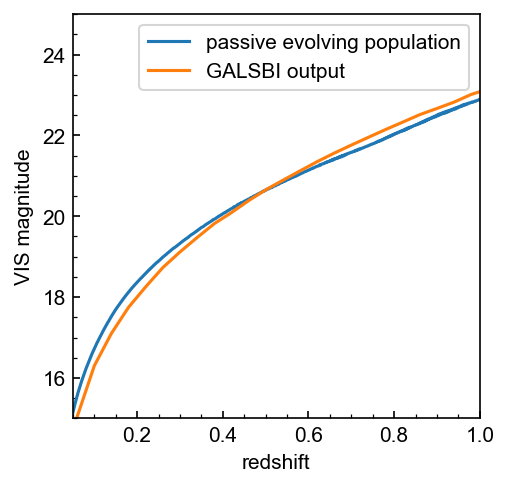

In [8]:
z_gal2, mi_star2 = np.loadtxt('/Users/ler13nrv/Downloads/passive_luminosity_function_VIS_EUCLID.dat').T
from scipy.interpolate import CubicSpline, splrep, splev
z_gal, mi_star,alpha_star,phi_star = np.loadtxt('/Users/ler13nrv/Downloads/GALSBI_luminosity_function_VIS_EUCLID.dat').T

plt.xlim(0.05,1.0)
plt.ylim(15,25)
plt.plot(z_gal2,mi_star2,label="passive evolving population")
plt.plot(z_gal,mi_star,label="GALSBI output")
plt.xlabel('redshift')
plt.ylabel('VIS magnitude')
plt.legend()

In [ ]:

## We apply some smoothing as we fitted the output of GALSBI to determine mi_star, alpha_star, and Phi_star, which result
## in a non-smooth evolution of the luminosity functions parameters. 
tck = splrep(z_gal, mi_star, s=0.1)
mi_star_func = lambda z: splev(z, tck)
mi_star = mi_star_func(z_gal)

tck = splrep(z_gal, alpha_star, s=0.1)
alpha_star_func = lambda z: splev(z, tck)
alpha_star = alpha_star_func(z_gal)

tck = splrep(z_gal, phi_star, s=0.1)
phi_star_func = lambda z: splev(z, tck)
schechter_params =  {'z_nodes': z_gal2, 'm_star': mi_star2}

##Let's assume a simple Schechter function for now
cat.set_schechter_params(schechter_params)
## estimate the photo_z for the spec-z sample. 
df_red = cat.estimate_photoz(df_red,method='differential_evolution',n_jobs=-1)

Set Schechter parameters: 1001 redshift nodes, z = [0.00, 1.50]
Estimating photo-z for 12489 galaxies using differential_evolution (all CPU cores)
Running photo-z estimation in parallel with -1 jobs...
✓ Photo-z estimation complete
  Valid estimates: 12489/12489 (100.0%)
  Computed L/L* ratio for 12489 galaxies
    Median L/L*: 1.137
    L/L* > 0.5: 10117 galaxies (81.0%)
    L/L* > 1.0: 6981 galaxies (55.9%)


Text(0, 0.5, '$z_{\\rm photo}$')

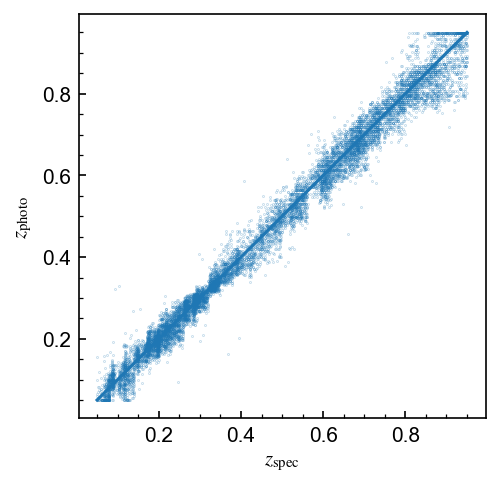

In [15]:
#Lets plot the results 
zarray = np.linspace(0.05,0.95,100)
plt.scatter(df_red.z_spec,df_red.z_phot,s=0.01)
plt.plot(zarray,zarray)
plt.xlabel(r'$z_{\rm spec}$')
plt.ylabel(r'$z_{\rm photo}$')

In [16]:
## Now we can compute the redshift offset of the method, and get a luminosity diagonistic for selected samples (L/L0 > 0.5 and L/LO > 1)

offset,metric = cat.calibrate_photoz_offset(df_red,train_fraction=0.50,compute_luminosity_diagnostics=True,n_nodes=9,random_seed=0,save_filepath='./offset.npz')

Photo-z Offset Calibration
Using 9 nodes from z=0.05 to z=0.95

Train set: 6244 galaxies (50.0%)
Validation set: 6245 galaxies (50.0%)

Estimating photo-z on training set using differential_evolution...
  Using all CPU cores
Running photo-z estimation in parallel with -1 jobs...

Pre-offset training metrics (all galaxies):
  Mean bias: -0.0021
  Mean NMAD scatter: 0.0193

Pre-offset training metrics (L/L* > 0.5):
  Mean bias: -0.0031  [N=5054, 80.9% of sample]
  Mean NMAD scatter: 0.0187

Pre-offset training metrics (L/L* > 1.0):
  Mean bias: -0.0049  [N=3558, 57.0% of sample]
  Mean NMAD scatter: 0.0182

Fitting offset function with 9 nodes...

Validating on held-out set...

Post-offset validation metrics (all galaxies):
  Mean bias: -0.0006
  Mean NMAD scatter: 0.0187

Post-offset validation metrics (L/L* > 0.5):
  Mean bias: 0.0008  [N=5079, 81.3% of sample]
  Mean NMAD scatter: 0.0181

Post-offset validation metrics (L/L* > 1.0):
  Mean bias: 0.0014  [N=3543, 56.7% of sample]
  Mea

In [17]:
##We can now compute the photoz with the redshift offset.
df_red = cat.estimate_photoz(df_red,method='differential_evolution',n_jobs=-1,offset=True)

Estimating photo-z for 12489 galaxies using differential_evolution (all CPU cores) with offset correction
Running photo-z estimation in parallel with -1 jobs...
✓ Photo-z estimation complete
  Valid estimates: 12489/12489 (100.0%)
  Computed L/L* ratio for 12489 galaxies
    Median L/L*: 1.156
    L/L* > 0.5: 10167 galaxies (81.4%)
    L/L* > 1.0: 7067 galaxies (56.6%)


Text(0, 0.5, '$z_{\\rm photo}$')

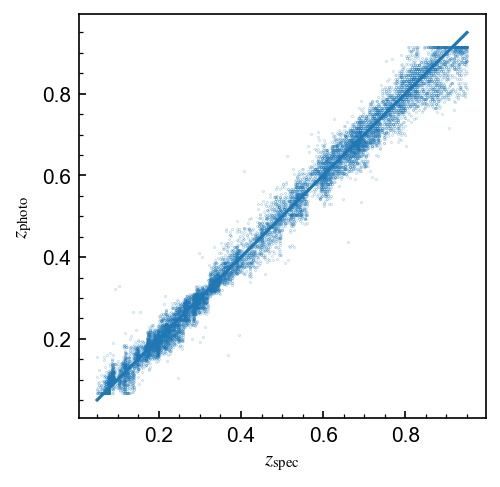

In [18]:
#Lets plot the results 

plt.scatter(df_red.z_spec,df_red.z_phot,s=0.01)
plt.plot(zarray,zarray)
plt.xlabel(r'$z_{\rm spec}$')
plt.ylabel(r'$z_{\rm photo}$')

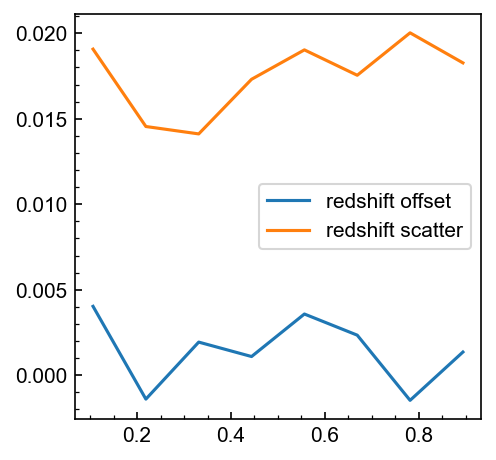

In [19]:
##And we can plot the diagnostic for the high-luminosity galaxies
plt.plot(metric['val_z_bins'],metric['val_l_10_bias'],label='redshift offset')
plt.plot(metric['val_z_bins'],metric['val_l_10_scatter'],label='redshift scatter')
plt.legend()

## Photo-z Estimation with Saved Parameters
The red-sequence estimation and the ridgelines determination can be do only once. 
So we can use the pre-determined red-sequence and pre-fitted ridge line parameters to estimate photo-z for new data.

In [16]:

z_gal2, mi_star2 = np.loadtxt('/Users/ler13nrv/Downloads/passive_luminosity_function_VIS_EUCLID.dat').T
z_gal, mi_star,alpha_star,phi_star = np.loadtxt('/Users/ler13nrv/Downloads/GALSBI_luminosity_function_VIS_EUCLID.dat').T

schechter_params =  {'z_nodes': z_gal2, 'm_star': mi_star2}#,'alpha':alpha_star,'phi':phi_star}
schechter_params2 =  {'z_nodes': z_gal, 'm_star': mi_star,'alpha':alpha_star,'phi':phi_star}

# Initialize pipeline with basic configuration
cat = RedCatalogue(
    colors=['gi', 'rz', 'iy'],  # Can also use [('g','i'), ('r','z'), ('i','y')]
    magnitude_col='mag_v2',
    z_spec_col='z_spec',
    z_min=0.05,
    z_max=0.95,
    delta_a=0.05,  # Fine spacing for a(z)
    delta_b=0.10,  # Medium spacing for b(z)
    delta_c=0.15,   # Coarse spacing for c(z)
)


cat.load_red_catalogue('./Q1_red_sample_15012026.parquet')
cat.load_ridge_line('./ridgeline_Q1_specz.npz')
cat.set_schechter_params(schechter_params2)
_=cat.load_offset('./offset.npz')

Loading Pre-Selected Red Catalogue
File: ./Q1_red_sample_15012026.parquet
Input: 12489 galaxies
After z cuts [0.05, 0.95]: 12489 galaxies
  Note: Schechter parameters not provided. Skipping L/L* computation.
Red catalogue loaded successfully!
Loaded ridge line parameters from ./ridgeline_Q1_specz.npz
  a(z): 19 nodes
  b(z): 10 nodes
  c(z): 7 nodes
  m_ref(z): 30 nodes
Set Schechter parameters: 26 redshift nodes, z = [0.06, 1.06]
  alpha(z) included
  phi(z) included


In [17]:
##And then you can simply estimate the photo-z estimation with any catalogues. Pass your photometric catalogue here
df_red = cat.estimate_photoz(cat.df_red,method='differential_evolution',n_jobs=-1,return_chi2=True)

Estimating photo-z for 12489 galaxies using differential_evolution (all CPU cores)
Running photo-z estimation in parallel with -1 jobs...
✓ Photo-z estimation complete
  Valid estimates: 12489/12489 (100.0%)
  Computed L/L* ratio for 12489 galaxies
    Median L/L*: 1.101
    L/L* > 0.5: 9588 galaxies (76.8%)
    L/L* > 1.0: 6715 galaxies (53.8%)


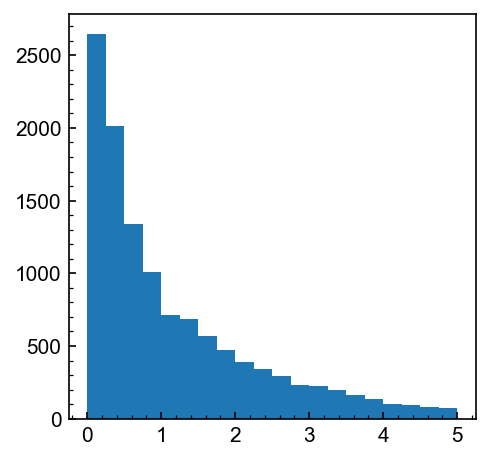

In [18]:
##You can then latter filter the red-galaxy from your photo-z catalogue with chi2 determination
_=plt.hist(df_red['chi2'],bins=20,range=(0,5))

## More example to come :
- smoothing of reference magnitude
- regularization of a(z), b(z), and C_int(z) coefficient
-  with sbatch to compute photoz for large datasets.
